NOTAS PARA ARMAR CLASE:
1. En el inicio poner texto introductorio al tema
1. En cada celda de código poner texto no solo explicando lo que hace sino mapeando con el proceso
1. Explicar los resultados o dejarlos como preguntas


## Aprendizaje Automático Avanzado - Support Vector Machine (SVM)

SVM ha resultado ser uno de los mejores clasificadores para un amplio abanico de situaciones, por lo que se considera uno de los referentes dentro del ámbito de machine learning.
SVM es un modelo de aprendizaje supervisado, por lo tanto requiere datos etiquetados. En el proceso de entrenamiento, el algoritmo analiza los datos de entrada y reconoce patrones en un espacio de características multidimensionales denominado hiperplano. Todos los ejemplos de entrada se representan como puntos en este espacio y se asignan a categorías de salida, de tal manera que las categorías se dividen de forma tan amplia y clara como sea posible.

El SVM genera un hiperplano óptimo de forma iterativa, que se utiliza para minimizar un error. La idea central de SVM es encontrar un hiperplano marginal máximo que mejor divida el conjunto de datos en clases ( en el caso que se use para clasificación).

Para esta práctica utilizaremos un conjunto de datos creado utilizando muestras de vino tinto y blanco. Las entradas incluyen pruebas objetivas (por ejemplo, valores de PH) y la salida se basa en datos sensoriales (mediana de al menos 3 evaluaciones realizadas por expertos en vinos). Cada experto calificó la calidad del vino entre 0 (muy mala) y 10 (muy excelente).


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import  metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

In [30]:



dfwine = pd.read_csv('/content/drive/MyDrive/AA_UGR_Practicas/Datasets/wineq.csv')
dfwine


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## PREPROCESAMIENTO

Variables de entrada:

acidez fija

acidez volátil

ácido cítrico

azúcar residual

cloruros

dióxido de azufre libre

dióxido de azufre total

densidad

pH

sulfatos

alcohol


Variable de salida :

calidad (puntuación entre 0 y 10)

In [31]:
dfwine.isnull().sum().sort_values(ascending=False)

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [32]:
dfwine['quality'].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


Veamos la información general del dataset

In [33]:
dfwine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [34]:
dfwine['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [35]:

dfwine.shape
dfwine.describe()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## ANALISIS UNIVARIADO

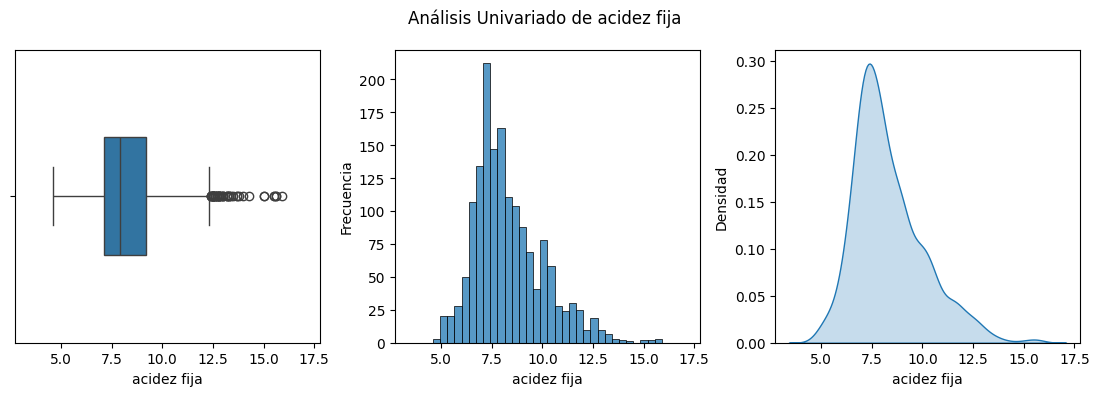

In [8]:
var = 'fixed acidity'
var_title = 'acidez fija'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

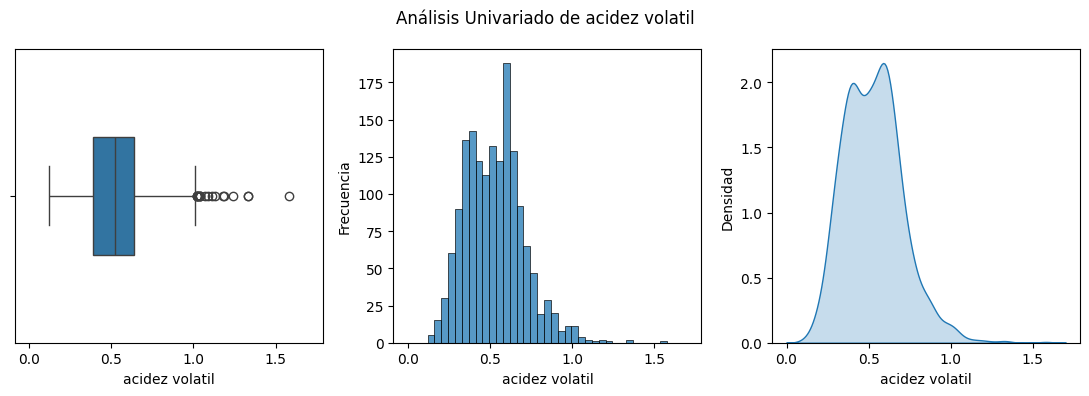

In [9]:

var = 'volatile acidity'
var_title = 'acidez volatil'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

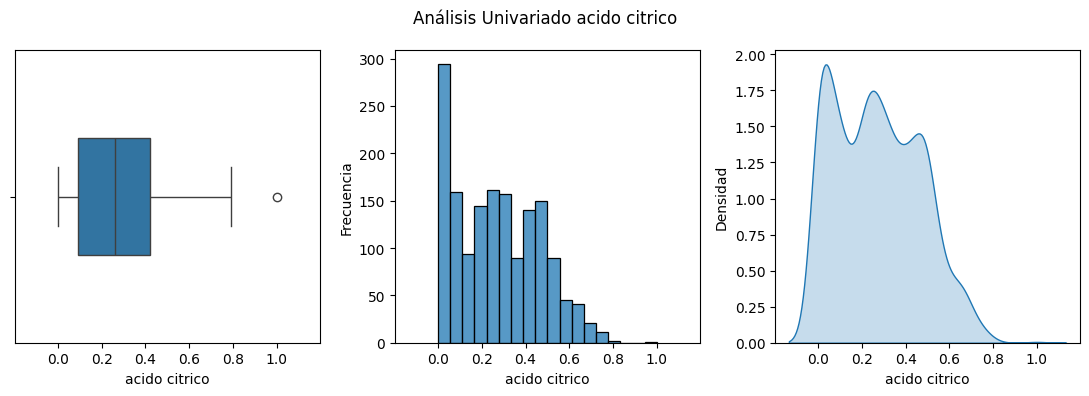

In [10]:
var = 'citric acid'
var_title = 'acido citrico'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado ' + var_title)

plt.tight_layout()

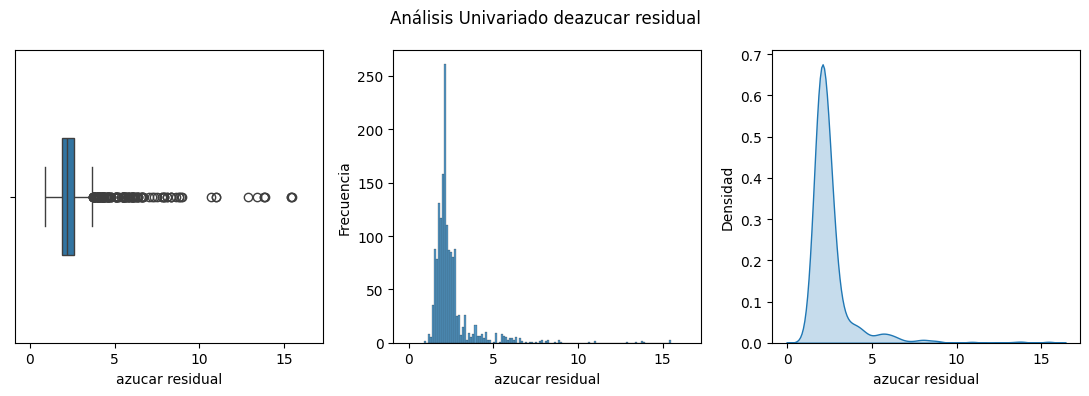

In [11]:
var = 'residual sugar'
var_title = 'azucar residual'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

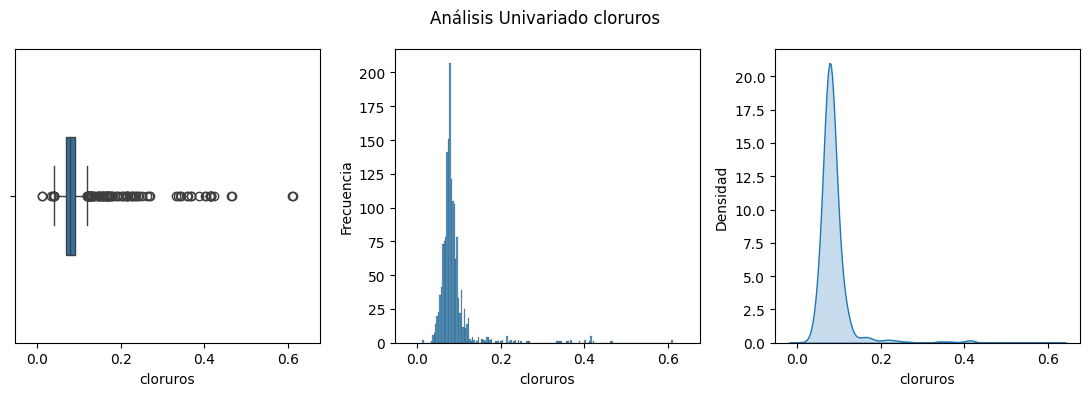

In [12]:
var = 'chlorides'
var_title = 'cloruros'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado ' + var_title)

plt.tight_layout()

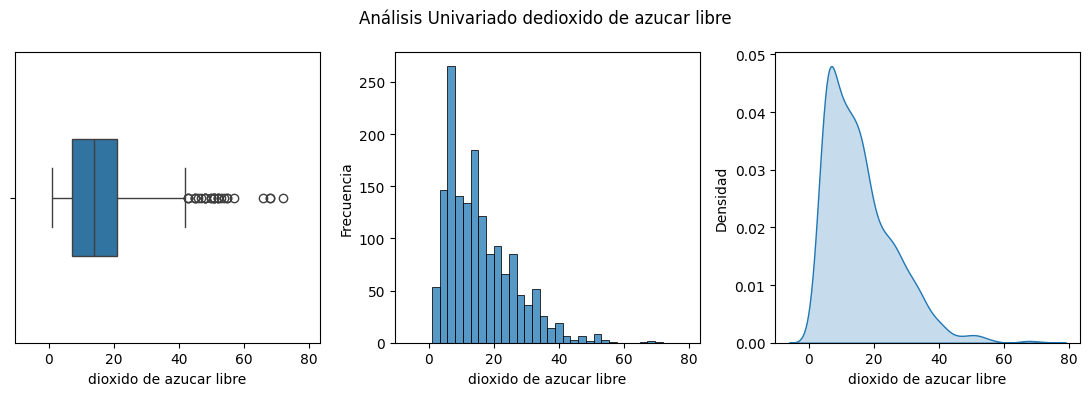

In [13]:
var = 'free sulfur dioxide'
var_title = 'dioxido de azucar libre'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

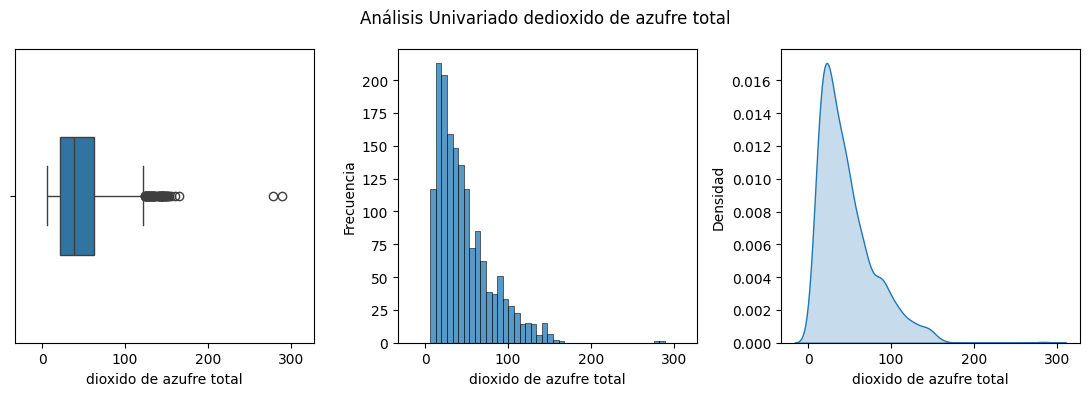

In [14]:
var = 'total sulfur dioxide'
var_title = 'dioxido de azufre total'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

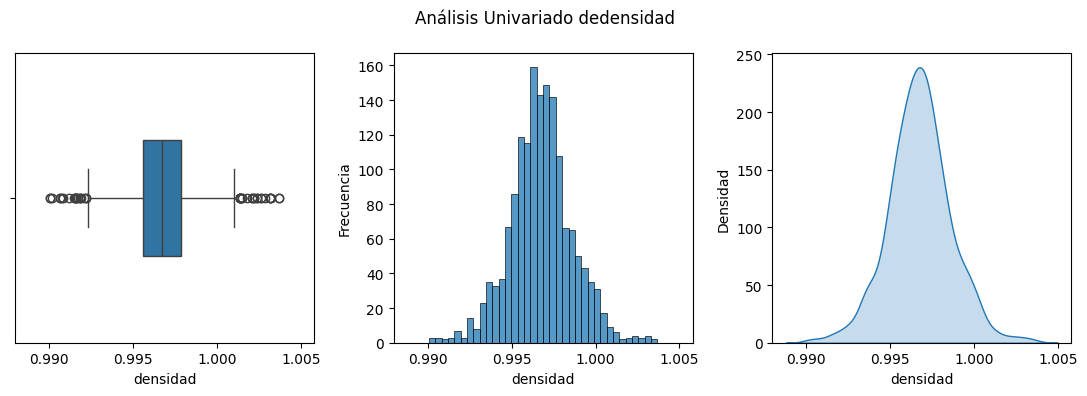

In [15]:
var = 'density'
var_title = 'densidad'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de' + var_title)

plt.tight_layout()

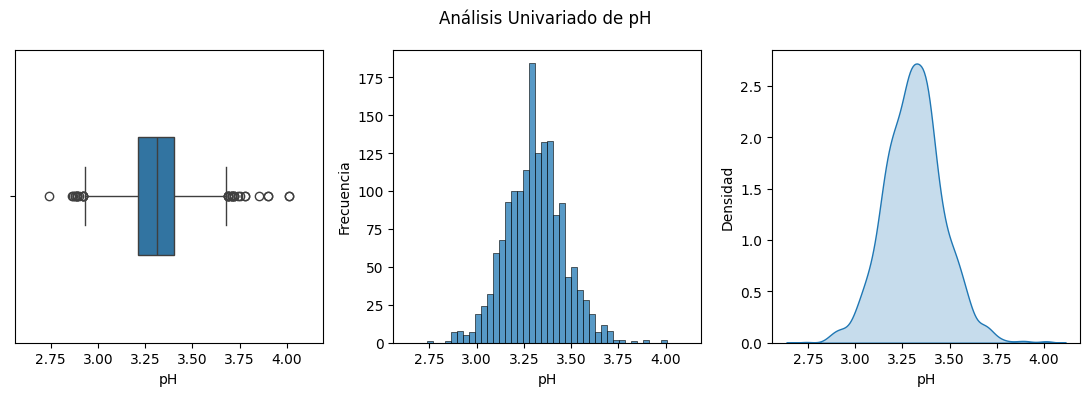

In [16]:
var = 'pH'
var_title = 'pH'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

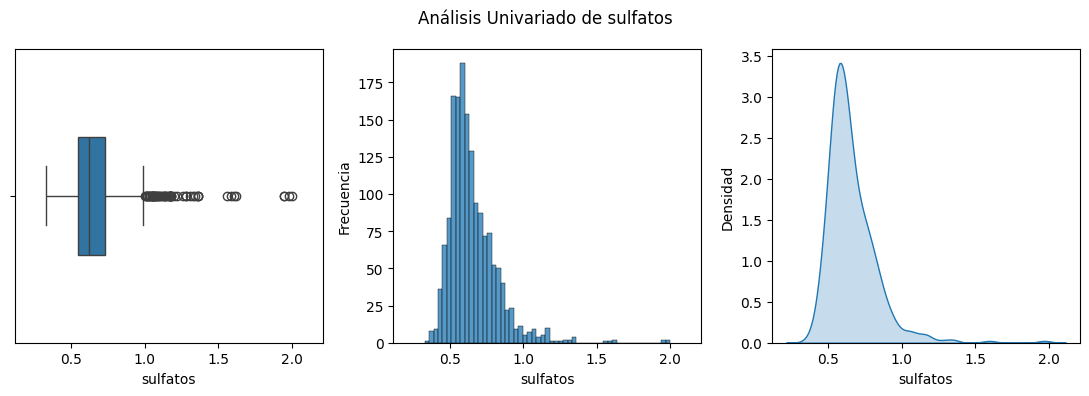

In [17]:
var = 'sulphates'
var_title = 'sulfatos'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

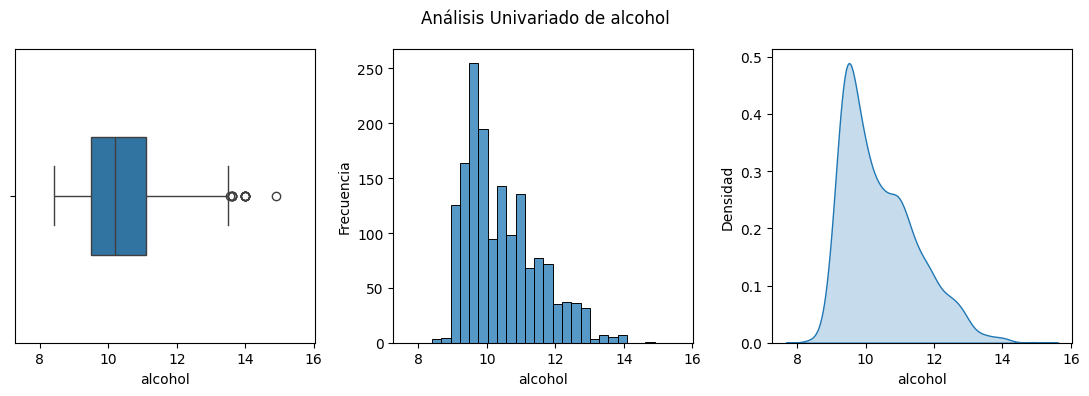

In [18]:
var = 'alcohol'
var_title = 'alcohol'

# Ajustes de la figura de Matplotlib
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(11, 4), sharex=True)

# Plotea el boxplot
sns.boxplot(data=dfwine[var], ax=ax[0], orient='h', width=0.4)
ax[0].set_xlabel(var_title)

# Plotea el histograma
sns.histplot(data=dfwine[var], ax=ax[1], kde=False)
ax[1].set_xlabel(var_title)
ax[1].set_ylabel('Frecuencia')

# Plotea la curva de densidad
sns.kdeplot(data=dfwine[var], ax=ax[2], fill=True)
ax[2].set_xlabel(var_title)
ax[2].set_ylabel('Densidad')

fig.suptitle('Análisis Univariado de ' + var_title)

plt.tight_layout()

In [19]:
sns.pairplot(dfwine, hue="quality", diag_kind="kde")

Output hidden; open in https://colab.research.google.com to view.

Miramos la correlación de las variables


In [36]:
X=dfwine.drop('quality', axis=1)

In [37]:
variables_cuantitativas= X.columns
for var in variables_cuantitativas:
    grupos = [grupo[var].values for nombre, grupo in dfwine.groupby('quality')]
    f_stat, p_valor = stats.f_oneway(*grupos)
    print(f"ANOVA para {var}: F-statistic = {f_stat}, p-value = {p_valor}")



ANOVA para fixed acidity: F-statistic = 6.283081158221344, p-value = 8.793966623816744e-06
ANOVA para volatile acidity: F-statistic = 60.91399283161238, p-value = 3.326465060517583e-58
ANOVA para citric acid: F-statistic = 19.690664466199717, p-value = 4.421091574500041e-19
ANOVA para residual sugar: F-statistic = 1.0533735778522084, p-value = 0.3846187754292449
ANOVA para chlorides: F-statistic = 6.035638592358694, p-value = 1.526539024860758e-05
ANOVA para free sulfur dioxide: F-statistic = 4.754233103987794, p-value = 0.00025708272340177853
ANOVA para total sulfur dioxide: F-statistic = 25.4785095182643, p-value = 8.533598445272067e-25
ANOVA para density: F-statistic = 13.396356896972382, p-value = 8.124394737040528e-13
ANOVA para pH: F-statistic = 4.341764303214791, p-value = 0.00062843887009581
ANOVA para sulphates: F-statistic = 22.273376089595672, p-value = 1.2258900918533501e-21
ANOVA para alcohol: F-statistic = 115.85479746682736, p-value = 1.2098951580566747e-104


<Axes: >

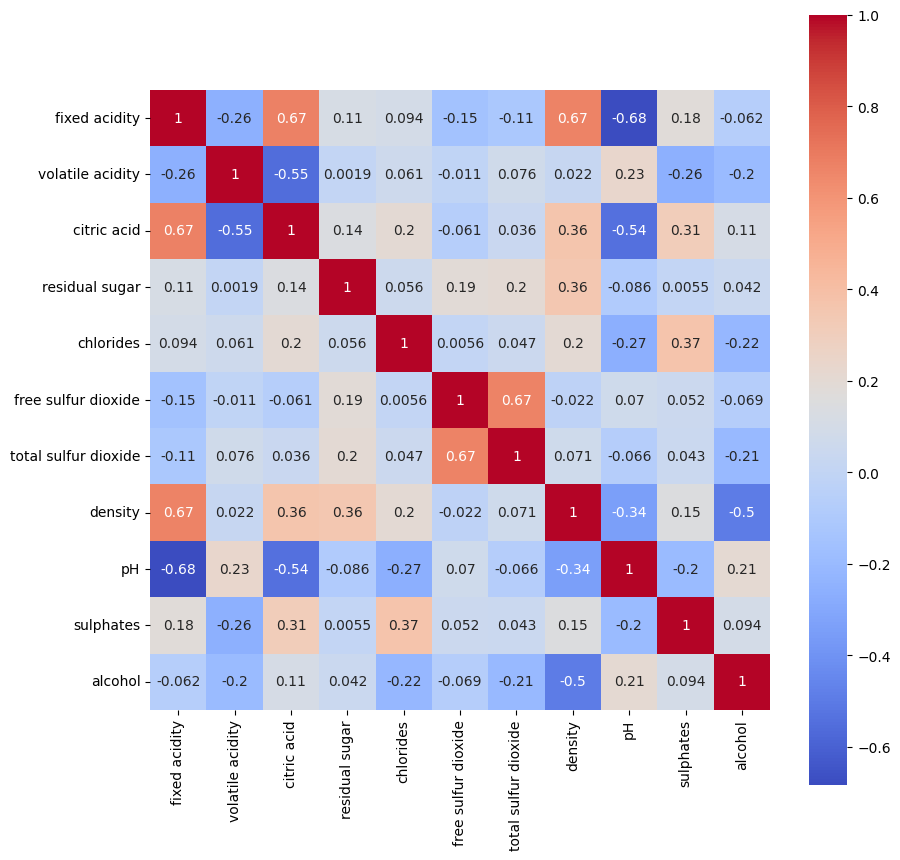

In [38]:
correlation = X.corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,vmax=1,square=True,annot=True,cmap='coolwarm')

In [39]:
y=dfwine.quality
#X=dfwine['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar','chlorides','free sulfur dioxide', 'density', 'pH',  'sulphates', 'alcohol']         0
#dfwine.drop('total sulfur dioxide', axis=1, inplace=True)




Particionamos


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 40)



Escalamos los datos porque tienen dimensiones muy diferentes


In [41]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_array = sc.fit_transform(X_train.values)
X_train = pd.DataFrame(X_train_array, index=X_train.index, columns=X_train.columns)
X_test_array = sc.transform(X_test.values)
X_test = pd.DataFrame(X_test_array, index=X_test.index, columns=X_test.columns)


Ponemos a entrenar el modelo


In [42]:
clf=SVC(kernel='rbf').fit(X_train,y_train)


In [43]:
y_pred=clf.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         8
           5       0.69      0.83      0.75       136
           6       0.59      0.67      0.63       125
           7       0.57      0.19      0.29        42
           8       0.00      0.00      0.00         6

    accuracy                           0.64       320
   macro avg       0.31      0.28      0.28       320
weighted avg       0.60      0.64      0.60       320



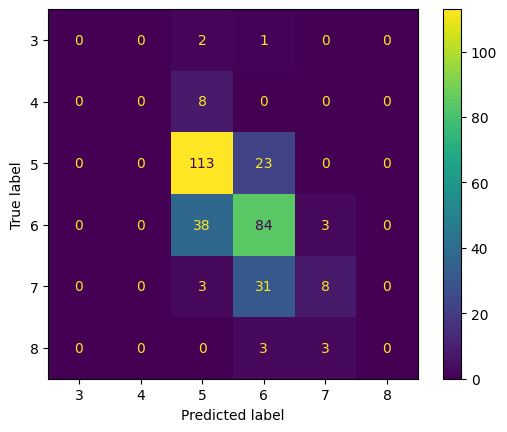

In [44]:
mc_clf=confusion_matrix(y_test, y_pred) #Matriz de confusion con las etiquetas reales de Test y los valores predichos
mc_clf = metrics.ConfusionMatrixDisplay(confusion_matrix = mc_clf, display_labels = ['3', '4', '5','6','7','8'] ) # edible=e=0, poisonous=p=1 ,display_labels = ['edible', 'poisonous']
mc_clf.plot()
# Reporte de clasificación
print(classification_report(y_test, y_pred))

# Conclusiones
El modelo tiene un Accuracy del 0.64, podría ser aceptable por el contexto de aplicación.

Analizando la sensibilidad de cada una de las clases, podemos apreciar que tiene dificultades para encotrar las calidades 3, 4, y 8 que está desbalanceadas. La clase 7 la confundió bastante con la 6.

Quizas con un pre-procesamiento de las mismas, u obteniendo más instancias de esas clases mejoraría la calidad del modelo.

Otra posibilidad sería acotar el alcance del modelo a las clases 5,6 y 7


## Tarea
1. Reducir el alcance a las clases 5  6 y 7
2. Modificar hiperparametros y evaluar los resultados
